In [ ]:
# 创建一个Python=3.10的新环境 conda create -n YOLO python=3.10
!pip install ultralytics -i https://pypi.tuna.tsinghua.edu.cn/simple 

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 2.2 MB/s eta 0:00:00a 0:00:01
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/5c/c0/e71b94b20ccf9effb38d7147c0064c08c622309fd487b1b677771a97d18c/scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/e0/a9/023730ba63db1e494a271cb018dcd361bd2c917ba7004c3e49d5daf795a2/py_cpuinfo-9.0.0-py3-none-any.whl (22 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 2.2 MB/s eta 0:00:0000:0100:01
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/b2/fe/81695a1aa331a842b582453b605175f419fe8540355886031328089d840a/sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/9 [sympy]
      Successfully uninstalled sympy-1.13.3━━━━━━━━━━━━━━━━━━━━━━━ 3/9 [sympy]
   ━━━━━━━━━━━━━━━━━━━━━━━

### 1.使用YOLO进行单张照片推理

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov10n.pt", task='detect')

# Predict with the model
results = model(source="./ultralytics-main/ultralytics/assets/bus.jpg", save=True, conf=0.05)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(results[0].plot()[:,:,::-1])
plt.axis('off')

### 2.打开摄像头实时推理

In [ ]:
from ultralytics import YOLO
import cv2
import time

# 加载 YOLO 模型
print("正在加载 YOLO 模型...")
model = YOLO("yolov10n.pt")  # 可以换成 yolov8n.pt, yolo11s.pt 等
print("模型加载完成！")

# 打开摄像头
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

if not cap.isOpened():
    print("错误：无法打开摄像头")
    exit()

print("摄像头已打开")
print("按 'q' 退出，按 's' 保存当前帧")

# FPS 计算
fps_time = time.time()
fps = 0

while True:
    # 读取帧
    ret, frame = cap.read()
    
    if not ret:
        print("错误：无法读取摄像头帧")
        break
    
    # YOLO 推理
    results = model(
        frame,
        conf=0.5,  # 置信度阈值
        iou=0.45,  # NMS IOU 阈值
        verbose=False  # 不打印日志
    )
    
    # 绘制检测结果
    annotated_frame = results[0].plot()
    
    # 计算 FPS
    current_time = time.time()
    fps = 1 / (current_time - fps_time)
    fps_time = current_time
    
    # 显示 FPS
    cv2.putText(annotated_frame, f'FPS: {fps:.1f}', (10, 30), 
               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    # 显示结果
    cv2.imshow('YOLO Real-time Detection', annotated_frame)
    
    # 按键处理
    key = cv2.waitKey(1) & 0xFF
    
    if key == ord('q'):
        print("退出程序")
        break
    elif key == ord('s'):
        filename = f'yolo_capture_{int(time.time())}.jpg'
        cv2.imwrite(filename, annotated_frame)
        print(f"已保存: {filename}")

# 释放资源
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)
print("摄像头已关闭")

### 3.迁移训练

In [6]:
from ultralytics import YOLO

# Load a model
model = YOLO('yolov10n.pt')  # 指定本地路径，不然会下载模型

# Train the model
model.train(data='coco128.yaml', epochs=10, imgsz=640)
#model.train(data='drink.yaml', epochs=10, imgsz=640)

New https://pypi.org/project/ultralytics/8.3.223 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.163 🚀 Python-3.10.18 torch-2.7.1 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

100%|██████████| 6.66M/6.66M [00:01<00:00, 4.84MB/s]
Unzipping /Users/silva/Desktop/2025JDRC/day2-PM/YOLO-demo_stu/datasets/coco128.zip to /Users/silva/Desktop/2025JDRC/day2-PM/YOLO-demo_stu/datasets/coco128...: 100%|██████████| 263/263 [00:00<00:00, 4435.61file/s]

Dataset download success ✅ (23.8s), saved to /Users/silva/Desktop/2025JDRC/day2-PM/YOLO-demo_stu/datasets


                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1      9856  ultralytics.nn.modules.block.SCDown          [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 

YOLOv10n summary: 223 layers, 2,775,520 parameters, 2,775,504 gradients, 8.7 GFLOPs

Transferred 595/595 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2244.9±970.7 MB/s, size: 50.9 KB)


train: Scanning /Users/silva/Desktop/2025JDRC/day2-PM/YOLO-demo_stu/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<00:00, 5175.96it/s]

...

                   all        128        929      0.812        0.6      0.718      0.551

10 epochs completed in 0.265 hours.


Optimizer stripped from runs/detect/train2/weights/last.pt, 5.9MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 5.9MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.163 🚀 Python-3.10.18 torch-2.7.1 CPU (Apple M2)
YOLOv10n summary (fused): 102 layers, 2,299,264 parameters, 0 gradients, 6.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:16<00:00,  4.05s/it]


                   all        128        929      0.811      0.601      0.718      0.551
                person         61        254       0.89      0.636      0.789       0.58
               bicycle          3          6      0.639      0.333      0.304      0.229
                   car         12         46      0.742      0.326      0.426       0.23
            motorcycle          4          5          1      0.933      0.995      0.847
              airplane          5          6      0.817          1      0.995      0.897
                   bus          5          7      0.817      0.714       0.75      0.639
                 train          3          3      0.693          1      0.995      0.791
                 truck          5         12       0.83      0.407       0.51      0.315
                  boat          2          6          1      0.503      0.711      0.442
         traffic light          4         14      0.711      0.143      0.186      0.171
             stop sig

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x13d8fa7d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,   

### 4.加载训练好的模型进行预测

In [7]:
model = YOLO("./runs/detect/train2/weights/best.pt") 
model.info()

YOLOv10n summary: 223 layers, 2,775,520 parameters, 0 gradients, 8.7 GFLOPs


(223, 2775520, 0, 8.7404288)

In [8]:
result = model.predict(source="./test/test.png",save_txt=True, imgsz=416, save_conf=True, save=True)


image 1/1 /Users/silva/Desktop/DL/PPT/07-8 YOLO/YOLO-demo/test/test.png: 288x416 1 bicycle, 47.2ms
Speed: 0.7ms preprocess, 47.2ms inference, 0.1ms postprocess per image at shape (1, 3, 288, 416)
Results saved to runs/detect/predict2
1 label saved to runs/detect/predict2/labels


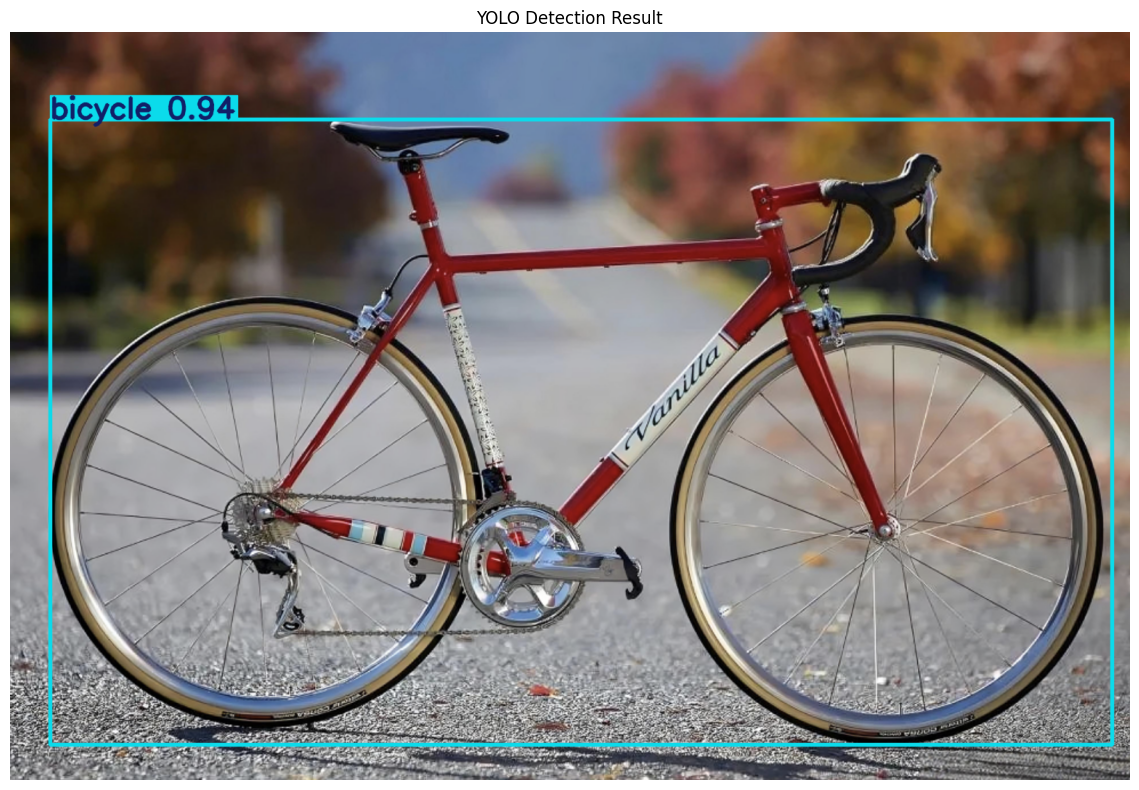

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

annotated_frame = result[0].plot()

# 将 BGR 转换为 RGB（YOLO 输出是 BGR 格式）
annotated_frame_rgb = annotated_frame[..., ::-1]

# 使用 matplotlib 显示
plt.figure(figsize=(12, 8))
plt.imshow(annotated_frame_rgb)
plt.axis('off')
plt.title('YOLO Detection Result')
plt.tight_layout()
plt.show()